<a href="https://colab.research.google.com/github/Illangovan2022/Iris_Deep_Learning_Project/blob/main/Deep_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import os

# 1. This will prompt you to select the kaggle.json file from your computer
files.upload()

# 2. Set up the Kaggle configuration directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the CASIA Iris Interval dataset directly from Kaggle
!kaggle datasets download -d swoyam2609/casia-iris-interval

# 4. Unzip the dataset and automatically overwrite existing files (-o)
!unzip -o -q casia-iris-interval.zip -d iris_dataset
print("Success! Your dataset is ready in the 'iris_dataset' folder.")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/swoyam2609/casia-iris-interval
License(s): MIT
100% 31.1M/31.1M [00:01<00:00, 20.4MB/s]

Success! Your dataset is ready in the 'iris_dataset' folder.


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define path to the unzipped images
# Note: CASIA usually organizes images by subject ID folders
base_dir = 'iris_dataset/CASIA-Iris-Interval'

# Innovation: Data Augmentation to improve model robustness [cite: 40]
datagen = ImageDataGenerator(
    rescale=1./255,            # Data cleaning/normalization [cite: 18]
    validation_split=0.2,      # Train-test split [cite: 20]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Training Data
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation Data
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2216 images belonging to 249 classes.
Found 423 images belonging to 249 classes.


In [4]:
from tensorflow.keras import layers, models

# Innovation: Use of pre-trained Transfer Learning model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers [cite: 26]

# Build the final model architecture [cite: 22, 26]
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Optimization technique to prevent overfitting [cite: 43]
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 249)            │       127,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,041,593 (11.60 MB)

 Trainable params: 783,609 (2.99 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.0176 - loss: 5.5410 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0355 - val_loss: 5.0952 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.0334 - loss: 5.0994 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0993 - val_loss: 4.6749 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.0650 - loss: 4.7232 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1726 - val_loss: 4.2589 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.1110 - loss: 4.3008 - precision: 0.8750 - recall: 0.0032 - val_accuracy: 0.2861 - val_loss: 3.7425 - val_precision: 1.0000 - val_recall: 0.0024
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.1643 - loss: 3.9174 - precision: 0.8182 - recall: 0

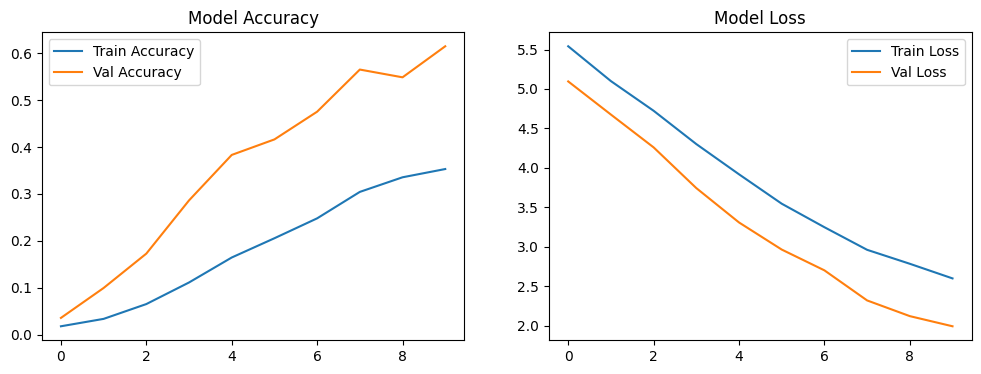

In [5]:
import matplotlib.pyplot as plt

# Start the training process [cite: 27]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10 # You can increase this for better accuracy
)

# Visualization: Training vs Validation plots [cite: 35, 36]
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

Saving S1047R01.jpg to S1047R01.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


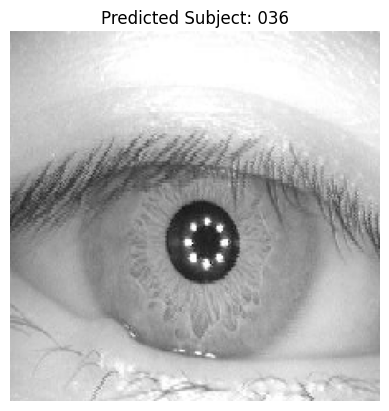

Confidence Score: 8.91%


In [7]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Upload your test photo
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. Load and Preprocess the image
    path = '/content/' + fn
    img = image.load_img(path, target_size=(224, 224)) # Must match model input
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Normalization (Crucial!)

    # 3. Make Prediction
    classes = model.predict(x)
    predicted_class_index = np.argmax(classes)

    # Get the subject label from the generator
    labels = (train_generator.class_indices)
    labels = dict((v,k) for k,v in labels.items())
    result = labels[predicted_class_index]

    # 4. Display Result
    plt.imshow(img)
    plt.title(f"Predicted Subject: {result}")
    plt.axis('off')
    plt.show()

    print(f"Confidence Score: {np.max(classes) * 100:.2f}%")

In [8]:
# Save the model to your Colab session memory
model.save('iris_model.h5')
print("Model saved as iris_model.h5")

Model saved as iris_model.h5
